In [1]:
using PyPlot
using JLD2
using Statistics
using ProgressBars
import PhysicalConstants.CODATA2018: c_0
using Unitful
using MAT
using HDF5

In [69]:
function load_crop_imgs(filenames, pathdir, x_crop, y_crop)
    imgs_atoms, imgs_bkg, imgs_dark, amplitude_laser = [], [], [], []

    for filename in filenames
        filename = pathdir*"/"*filename
        h5open(filename, "r") do file
            img_atoms = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"])), x_crop, y_crop)
            img_bkg = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"])), x_crop, y_crop)
            img_dark = crop_img(convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"])), x_crop, y_crop)
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark), push!(amplitude_laser, read_attribute(file["globals"], "vert_abs_img_amp_high"))
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark, amplitude_laser
end

function crop_img(img, x_crop, y_crop)
    return img[y_crop, x_crop]
end

function load_t_exp(filepath)
    h5open(filepath, "r") do file
        return read_attribute(file["globals"], "vert_blue_imaging_pulse_duration_high")
    end
end

load_t_exp (generic function with 1 method)

In [84]:
pathdir = "Y:/StructuralPhaseTransition/2026/02/11/0001" # Stripes 90°

x_crop = [1300:1700;]
y_crop = [1750:2150;]

shots = 380

size_pxl = 0.1966e-6; # New pxl size since 2025/12/31

### Crop images

In [85]:
files_path = readdir(pathdir)
Imgs_atoms_crop, Imgs_bkg_crop, Imgs_dark_crop, Amplitude_laser = load_crop_imgs(files_path, pathdir, x_crop, y_crop)
τ_exp = load_t_exp(joinpath(pathdir, readdir(pathdir)[1])); # In s, if the exposure time is the same for all images;

### Check validity of masks

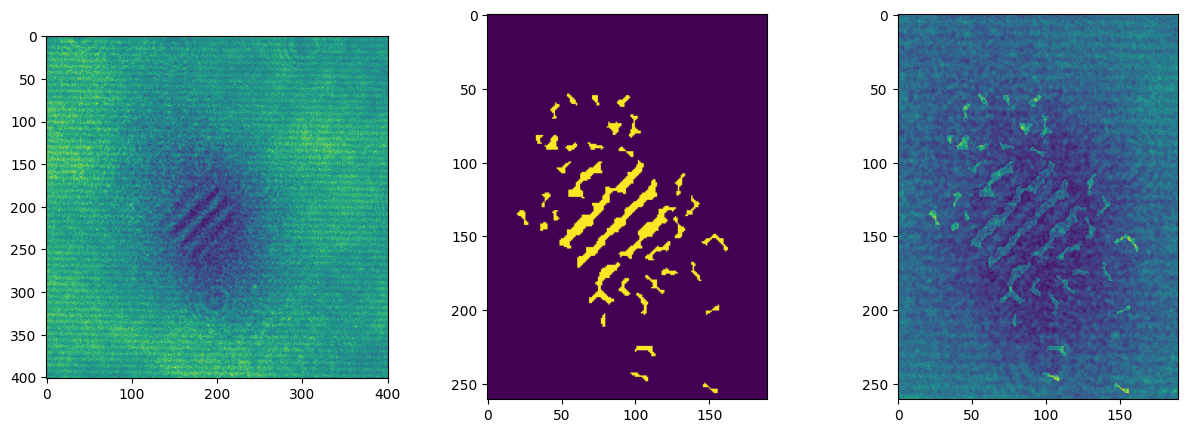

In [86]:
i = 5
file = matopen("Saved_masks/$i.mat")
mask = read(file, "binaryMask")'
xStart = read(file, "xStart")
yStart = read(file, "yStart")
close(file)

close("all")
fig, axs = subplots(1, 3, figsize=(15, 5))

axs[1].imshow(Imgs_atoms_crop[i])

axs[2].imshow(mask)

img_cropped = Imgs_atoms_crop[i][Int(xStart):size(mask)[1]+Int(xStart)-1, Int(yStart):size(mask)[2]+Int(yStart)-1]

axs[3].imshow(img_cropped .* mask .+ img_cropped)

# pygui(true); show()
pygui(false);

### Load masks

In [87]:
masks, xStarts, yStarts = [], [], []

for i = 1:length(Imgs_atoms_crop)
    file = matopen("Saved_masks/$i.mat")
    push!(masks, read(file, "binaryMask")')
    push!(xStarts, read(file, "xStart")')
    push!(yStarts, read(file, "yStart")')
    close(file)
end

In [88]:
Iatoms_masked, Ibkg_masked, Idark_masked = zeros(length(Imgs_atoms_crop)), zeros(length(Imgs_atoms_crop)), zeros(length(Imgs_atoms_crop))

# Convertion factor to go from electrons to photons
if length(τ_exp) == 1
    Convertion_factor = 0.107 / (0.85 * τ_exp)
end

for i = ProgressBar(1:size(Imgs_atoms_crop)[1])
    if length(τ_exp) > 1
        Convertion_factor = 0.107 / (0.85 * τ_exp[i])
    end
    mask = masks[i]
    Iatoms_masked[i] = sum(Imgs_atoms_crop[i][Int(xStarts[i]):size(mask)[1]+Int(xStarts[i])-1, Int(yStarts[i]):size(mask)[2]+Int(yStarts[i])-1] .* mask)  * Convertion_factor / (length(mask[mask.>0])*size_pxl^2)
    Ibkg_masked[i] = sum(Imgs_bkg_crop[i][Int(xStarts[i]):size(mask)[1]+Int(xStarts[i])-1, Int(yStarts[i]):size(mask)[2]+Int(yStarts[i])-1] .* mask)  * Convertion_factor / (length(mask[mask.>0])*size_pxl^2)
    Idark_masked[i] = sum(Imgs_dark_crop[i][Int(xStarts[i]):size(mask)[1]+Int(xStarts[i])-1, Int(yStarts[i]):size(mask)[2]+Int(yStarts[i])-1] .* mask)  * Convertion_factor / (length(mask[mask.>0])*size_pxl^2)
    end

0.0%┣                                              ┫ 0/380 [00:00<00:00, -0s/it]
10.3%┣████▍                                      ┫ 39/380 [00:00<00:00, 735it/s]
21.3%┣█████████▏                                 ┫ 81/380 [00:00<00:00, 777it/s]
33.7%┣██████████████▏                           ┫ 128/380 [00:00<00:00, 820it/s]
44.7%┣██████████████████▉                       ┫ 170/380 [00:00<00:00, 818it/s]
55.8%┣███████████████████████▍                  ┫ 212/380 [00:00<00:00, 814it/s]
70.3%┣█████████████████████████████▌            ┫ 267/380 [00:00<00:00, 838it/s]
84.7%┣███████████████████████████████████▋      ┫ 322/380 [00:00<00:00, 867it/s]
97.6%┣█████████████████████████████████████████ ┫ 371/380 [00:00<00:00, 876it/s]
100.0%┣█████████████████████████████████████████┫ 380/380 [00:00<00:00, 887it/s]
100.0%┣█████████████████████████████████████████┫ 380/380 [00:00<00:00, 885it/s]


### Reorganize the data per datasets

In [110]:
nbr_amp_laser = length(unique(Amplitude_laser))
nbr_repetition = Integer(length(files_path)/nbr_amp_laser)

Imgs_atoms_crop_ds, Imgs_bkg_crop_ds, Imgs_dark_crop_ds = zeros((nbr_amp_laser, nbr_repetition)), zeros((nbr_amp_laser, nbr_repetition)), zeros((nbr_amp_laser, nbr_repetition))

for i in 1:length(Iatoms_masked)
        idx_line = findfirst(==(Amplitude_laser[i]), unique(Amplitude_laser))
        idx_row = floor(Int64, (i-1)/nbr_amp_laser+1)
        Imgs_atoms_crop_ds[idx_line, idx_row] = Iatoms_masked[i]
        Imgs_bkg_crop_ds[idx_line, idx_row] = Ibkg_masked[i]
        Imgs_dark_crop_ds[idx_line, idx_row] = Idark_masked[i]
end

### Compute mean/std

In [113]:
Mean_atoms, Mean_bkg, Mean_dark, Mean_bkg_atoms = zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser)
Std_atoms, Std_bkg, Std_dark, Std_bkg_atoms = zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser), zeros(nbr_amp_laser)

for i = 1:nbr_amp_laser
    atoms, bkg, dark, bkg_atoms = [], [], [], []
    for j = 1:size(Imgs_atoms_crop_ds)[2]
        push!(atoms, Imgs_atoms_crop_ds[i, j]), push!(bkg, Imgs_bkg_crop_ds[i, j]), push!(dark, Imgs_dark_crop_ds[i, j]), push!(bkg_atoms, Imgs_bkg_crop_ds[i, j]-Imgs_atoms_crop_ds[i, j])
    end
    if length(atoms) > 0
        Mean_atoms[i], Mean_bkg[i], Mean_dark[i], Mean_bkg_atoms[i] = mean(atoms), mean(bkg), mean(dark), mean(bkg_atoms)
        Std_atoms[i], Std_bkg[i], Std_dark[i], Std_bkg_atoms[i] = std(atoms), std(bkg), std(dark), std(bkg_atoms)
    end
end

### Save data

In [119]:
@save "Saved_exp_data/Intensity_integrated_mask_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds Mean_atoms Mean_bkg Mean_dark Mean_bkg_atoms Std_atoms Std_bkg Std_dark Std_bkg_atoms;